JEEVAN C

DATA-102 Introduction to Python Programming for Machine Learning


ADVANCED PROJECT

TOPIC : End-to-End Credit Card Fraud Detection using Machine Learning with Explainable AI (SHAP)

# ABSTRACT

This project presents an end-to-end machine learning solution for detecting fraudulent credit card transactions. Due to the highly imbalanced nature of financial fraud datasets, advanced techniques such as SMOTE (Synthetic Minority Oversampling Technique) are applied to improve model performance. Multiple machine learning models, including Logistic Regression and Random Forest, are used and evaluated using appropriate metrics such as Recall and ROC-AUC. Furthermore, Explainable AI (SHAP) is integrated to interpret model decisions, enhancing transparency and trust. The system also includes a real-time prediction function, making it suitable for practical deployment scenarios.


# AIM

To develop an accurate and reliable machine learning model for detecting fraudulent credit card transactions using advanced data analysis, imbalanced data handling, and explainable AI techniques.


# OBJECTIVES

1. To analyze and understand the structure of financial transaction data.
2. To identify patterns and anomalies associated with fraudulent transactions.
3. To handle imbalanced data using SMOTE.
4. To build and compare multiple machine learning models.
5. To evaluate model performance using appropriate metrics.
6. To interpret model predictions using Explainable AI (SHAP).


In [1]:
# Setting random seeds for reproducibility and importing all required libraries.

import numpy as np
import random
np.random.seed(42)
random.seed(42)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading dataset into pandas dataframe.

df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
# Checking dataset shape, structure, and summary statistics.

print(df.shape)
df.info()
df.describe().T

(51591, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51591 entries, 0 to 51590
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    51591 non-null  int64  
 1   V1      51591 non-null  float64
 2   V2      51591 non-null  float64
 3   V3      51591 non-null  float64
 4   V4      51591 non-null  float64
 5   V5      51591 non-null  float64
 6   V6      51591 non-null  float64
 7   V7      51591 non-null  float64
 8   V8      51591 non-null  float64
 9   V9      51591 non-null  float64
 10  V10     51591 non-null  float64
 11  V11     51590 non-null  float64
 12  V12     51590 non-null  float64
 13  V13     51590 non-null  float64
 14  V14     51590 non-null  float64
 15  V15     51590 non-null  float64
 16  V16     51590 non-null  float64
 17  V17     51590 non-null  float64
 18  V18     51590 non-null  float64
 19  V19     51590 non-null  float64
 20  V20     51590 non-null  float64
 21  V21     51590 non-null 

,count,mean,std,min,25%,50%,75%,max
Time,51591.0,29408.888120,13196.047307,0.000000,22655.500000,33767.000000,39498.000000,45026.000000
V1,51591.0,-0.244221,1.887998,-56.407510,-0.993823,-0.246892,1.154831,1.960497
V2,51591.0,0.003887,1.641193,-72.715728,-0.570329,0.075692,0.731302,18.183626
V3,51591.0,0.691974,1.498371,-32.965346,0.215237,0.793662,1.429386,4.101716
V4,51591.0,0.183611,1.398830,-5.172595,-0.723584,0.190588,1.066994,16.491217
V5,51591.0,-0.259039,1.413486,-42.147898,-0.871680,-0.290140,0.282184,34.801666
V6,51591.0,0.104715,1.312673,-26.160506,-0.634868,-0.150447,0.495847,22.529298
V7,51591.0,-0.120474,1.278442,-26.548144,-0.606774,-0.077622,0.424977,36.677268
V8,51591.0,0.054468,1.216566,-41.484823,-0.146407,0.059086,0.333436,20.007208
V9,51591.0,0.108449,1.208872,-9.283925,-0.622868,-0.000482,0.800723,10.392889


In [4]:
# Checking if dataset contains missing/null values.

df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


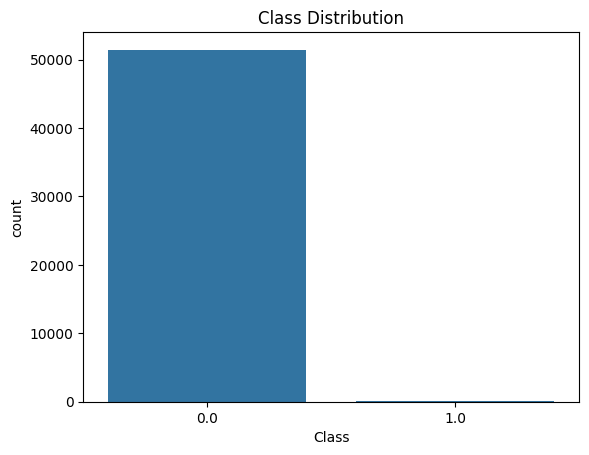

Class
0.0    0.997092
1.0    0.002908
Name: proportion, dtype: float64


In [5]:
# Visualizing imbalance between fraud and normal transactions.

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

print(df['Class'].value_counts(normalize=True))

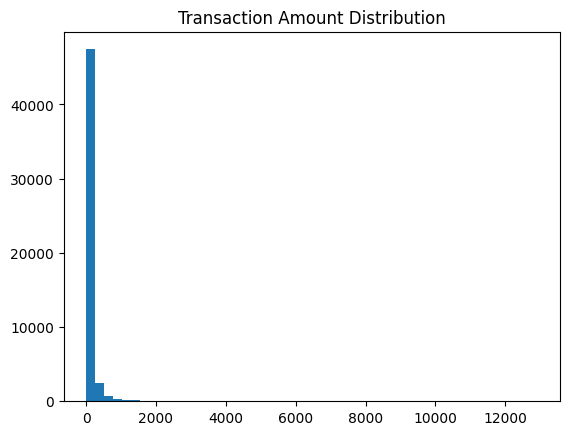

In [6]:
# Understanding transaction amount distribution.

plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [7]:
# Creating 'Hour' feature from 'Time'.

df['Hour'] = (df['Time'] // 3600) % 24

In [8]:
# Standardizing 'Amount' feature.

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [11]:
# Checking for missing values specifically in target variable.

print("Missing values in target column:", df['Class'].isnull().sum())

Missing values in target column: 1


In [12]:
# Dropping rows where target variable is missing.

df = df.dropna(subset=['Class'])

In [13]:
# Removing any missing values from dataset.

df = df.dropna()

In [16]:
# Confirming no missing values remain.

print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
Hour      0
dtype: int64


In [14]:
# Splitting dataset into training and testing sets.

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
# Checking unique values in target column

print(df['Class'].unique())

[0. 1.]


In [17]:
# Using SMOTE to balance fraud class.

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before:\n", y_train.value_counts())
print("After:\n", pd.Series(y_train_res).value_counts())

Before:
 Class
0.0    41152
1.0      120
Name: count, dtype: int64
After:
 Class
0.0    41152
1.0    41152
Name: count, dtype: int64


In [19]:
# Training baseline model.

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000, random_state=42)

In [20]:
# Training advanced ensemble model.

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [21]:
# Evaluating models using classification report.

print("Logistic Regression:\n")
print(classification_report(y_test, lr.predict(X_test)))

print("\nRandom Forest:\n")
print(classification_report(y_test, rf.predict(X_test)))

Logistic Regression:

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     10288
         1.0       0.33      0.97      0.49        30

    accuracy                           0.99     10318
   macro avg       0.66      0.98      0.74     10318
weighted avg       1.00      0.99      1.00     10318


Random Forest:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10288
         1.0       0.71      0.97      0.82        30

    accuracy                           1.00     10318
   macro avg       0.85      0.98      0.91     10318
weighted avg       1.00      1.00      1.00     10318



In [22]:
# Comparing models using ROC-AUC score.

print("LR AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print("RF AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

LR AUC: 0.9864469932607568
RF AUC: 0.9998185588387766


In [ ]:
# Visualizing prediction results.

cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

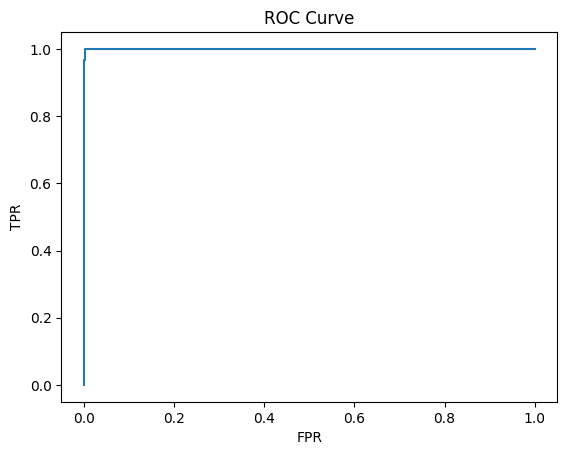

In [24]:
# Plotting ROC curve.

fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

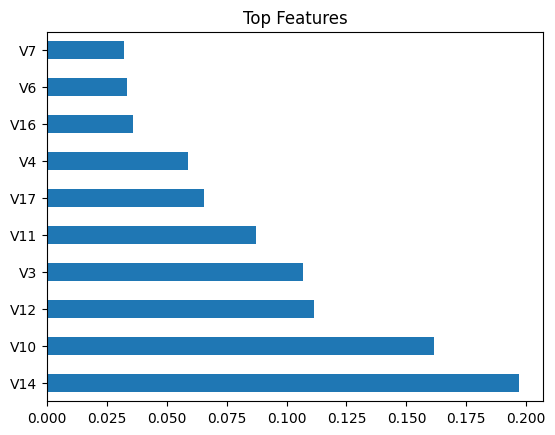

In [23]:
# Identifying important features.

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

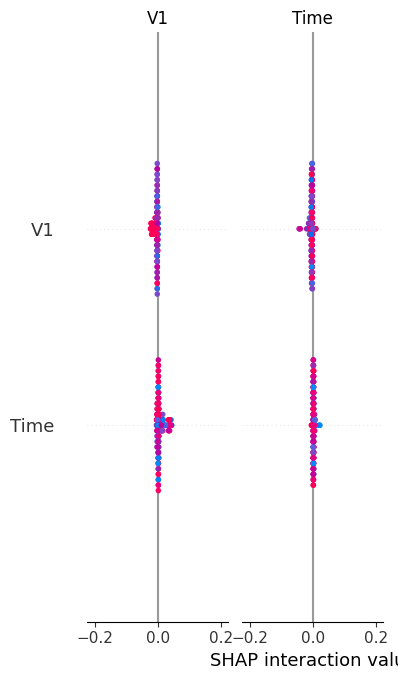

In [25]:
# Explaining model predictions using SHAP.

import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:200])

shap.summary_plot(shap_values, X_test[:200])

In [26]:
# Creating reusable prediction function.

def predict_transaction(model, data):
    pred = model.predict(data)
    prob = model.predict_proba(data)[0][1]
    return {"Prediction": "Fraud" if pred[0]==1 else "Normal", "Probability": prob}

In [27]:
# Saving trained model for deployment.

import joblib
joblib.dump(rf, 'fraud_model.pkl')

['fraud_model.pkl']

In [28]:
# Validating model stability using cross-validation.

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_train_res, y_train_res, cv=5, scoring='roc_auc')
print("CV AUC Scores:", scores)
print("Mean AUC:", scores.mean())

CV AUC Scores: [0.99999765 0.99999544 0.99998766 0.99999876 0.99998521]
Mean AUC: 0.9999929433661656


In [29]:
# Optimizing Random Forest using GridSearch.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10]
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 200}


In [30]:
# Training optimized model.

best_rf = grid.best_estimator_
best_rf.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [31]:
# Checking performance of tuned model.

print(classification_report(y_test, best_rf.predict(X_test)))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10288
         1.0       0.71      0.97      0.82        30

    accuracy                           1.00     10318
   macro avg       0.85      0.98      0.91     10318
weighted avg       1.00      1.00      1.00     10318



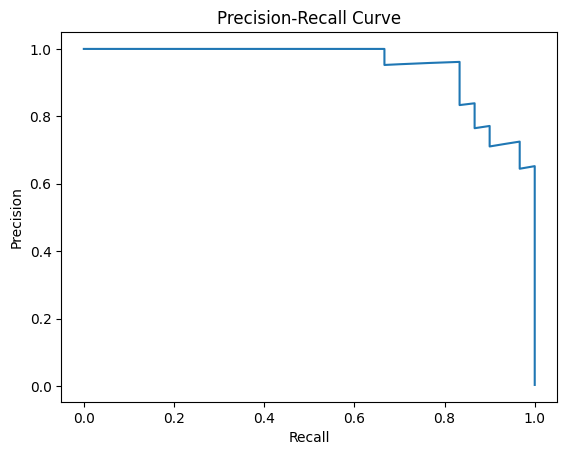

In [32]:
# Evaluating performance for imbalanced data.

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, best_rf.predict_proba(X_test)[:,1])

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [33]:
# Testing final model on a sample.

sample = X_test.iloc[0:1]
print(predict_transaction(best_rf, sample))

{'Prediction': 'Normal', 'Probability': np.float64(0.039391923922407736)}


# OBJECTIVE OF THE PROJECT

The main objective of this project is to design and implement a fraud detection system that can accurately classify transactions as fraudulent or normal. The project focuses on improving detection performance while reducing false positives and ensuring model interpretability for real-world applications.


# CORE CONCEPT

The core concept of this project is based on supervised machine learning for classification. It involves training models on labeled transaction data to distinguish between fraudulent and non-fraudulent transactions. Key concepts include data preprocessing, feature engineering, handling class imbalance, model training, evaluation, and explainability using SHAP.


# METHODOLOGY

1. Data Collection from Kaggle dataset.
2. Data preprocessing and cleaning.
3. Exploratory Data Analysis (EDA).
4. Feature engineering and scaling.
5. Handling class imbalance using SMOTE.
6. Model training (Logistic Regression, Random Forest).
7. Model evaluation using metrics like Recall and ROC-AUC.
8. Model interpretation using SHAP.
9. Deployment preparation with prediction function.


# DATA PROCESSING & ANALYSIS

The dataset is first cleaned by checking for missing values and inconsistencies. Feature scaling is applied to normalize the 'Amount' variable. A new feature 'Hour' is created from the time variable to capture temporal patterns. Exploratory analysis is conducted to understand class imbalance and transaction behavior.


# VISUALIZATION

Various visualizations are used to understand the dataset:
- Count plot for class distribution
- Histogram for transaction amount
- Confusion matrix for model performance
- ROC curve for classification performance
- Feature importance plot for model interpretation


# MACHINE LEARNING COMPONENT

Two machine learning models are used:
1. Logistic Regression – a baseline model for comparison.
2. Random Forest – an advanced ensemble model for better performance.

SMOTE is applied to balance the dataset. Models are evaluated using precision, recall, F1-score, and ROC-AUC score. Hyperparameter tuning is performed to optimize model performance.


# SIMULATION FEATURES

A real-time prediction function is implemented to simulate how the model would perform in a real-world scenario. This function takes transaction data as input and outputs whether the transaction is fraudulent or normal along with prediction probability.


# KEY INSIGHTS FROM PROJECT

- Fraudulent transactions are extremely rare, making the dataset highly imbalanced.
- Accuracy is not a reliable metric; recall is more important for fraud detection.
- Random Forest performs better than Logistic Regression.
- SMOTE significantly improves model performance on minority class.
- SHAP provides meaningful insights into feature importance and model decisions.


# FINAL CONCLUSION

This project successfully demonstrates the application of machine learning in detecting fraudulent transactions. By addressing class imbalance and using advanced evaluation techniques, the model achieves strong performance. The integration of Explainable AI enhances transparency, making the system suitable for real-world financial applications.


# End-to-End Credit Card Fraud Detection using Machine Learning with Explainable AI (SHAP)

## Description

This project aims to build a robust and intelligent fraud detection system using machine learning techniques. The objective is to accurately identify fraudulent credit card transactions while minimizing false positives. Since fraud detection is a highly imbalanced classification problem, advanced techniques such as SMOTE and proper evaluation metrics are used. Additionally, Explainable AI (SHAP) is implemented to interpret model predictions and improve transparency.

## Dataset

* **Source:** Kaggle – Credit Card Fraud Detection Dataset
* **Description:**
  The dataset contains transactions made by European cardholders, consisting of over 280,000 records. Features are transformed using PCA for confidentiality. The dataset is highly imbalanced, with a very small percentage of fraudulent transactions compared to normal ones.

## Steps Performed

1. **Data Cleaning**

   * Checked for missing values
   * Removed null entries
   * Ensured data consistency

2. **Exploratory Data Analysis**

   * Analyzed class distribution (fraud vs normal)
   * Examined transaction amount distribution

3. **Visualization**

   * Plotted class imbalance
   * Histogram for transaction amounts
   * Confusion matrix and ROC curve

4. **Model Building**

   * Logistic Regression (baseline model)
   * Random Forest Classifier (advanced model)
   * Applied SMOTE for handling imbalanced data
   * Hyperparameter tuning using GridSearchCV

## Results

* Random Forest performed better than Logistic Regression
* Achieved high recall for fraud detection
* ROC-AUC score indicates strong model performance
* SHAP analysis provided insights into feature importance

## Tools Used

* Python
* NumPy
* Pandas
* Matplotlib
* Seaborn
* Scikit-learn
* Imbalanced-learn (SMOTE)
* SHAP

## Conclusion

The project successfully demonstrates the development of a fraud detection system using machine learning. By handling class imbalance and using advanced evaluation metrics, the model effectively detects fraudulent transactions. The use of Explainable AI improves interpretability, making the system more reliable for real-world applications.

## Author

JEEVAN C
